Path to git repo: /home/matias/Documents/PhD/code


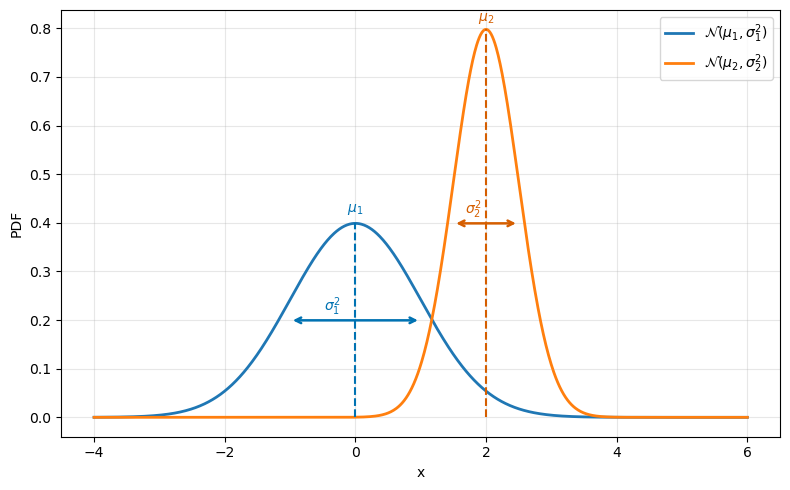

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

import git
import os

# Path to the root of the git repository
path_git = git.Repo('.', search_parent_directories=True).working_tree_dir
path_global = os.path.dirname(path_git)
print(f'Path to git repo: {path_global}')

# --- Colores aptos para daltónicos (Okabe–Ito) ---
blue   = "#0072B2"
orange = "#D55E00"

# --- Parámetros ---
mu1, sigma1 = 0, 1
mu2, sigma2 = 2, 0.5

# --- Rango para graficar ---
x = np.linspace(-4, 6, 1000)

# --- Gaussianas ---
gauss1 = norm.pdf(x, mu1, sigma1)
gauss2 = norm.pdf(x, mu2, sigma2)

# --- Figura ---
fig, ax = plt.subplots(figsize=(8,5))

ax.plot(x, gauss1, label=r'$\mathcal{N}(\mu_1,\sigma_1^2)$', lw=2)
ax.plot(x, gauss2, label=r'$\mathcal{N}(\mu_2,\sigma_2^2)$', lw=2)

# Alturas máximas
max1 = gauss1.max()
max2 = gauss2.max()

# --- Marcar medias ---
ax.vlines(mu1, 0, max1, color=blue, linestyle='--')
ax.vlines(mu2, 0, max2, color=orange, linestyle='--')

# --- Texto de medias debajo del eje ---
ax.text(mu1, max1+0.15, r'$\mu_1$', color=blue, ha='center', va='top', transform=ax.get_xaxis_transform())
ax.text(mu2, max2+0.2, r'$\mu_2$', color=orange, ha='center', va='top', transform=ax.get_xaxis_transform())

# --- Flecha horizontal: varianza sigma^2 ---
y1 = 0.5 * max1     # altura relativa para la flecha de gauss1
y2 = 0.5 * max2     # altura relativa para la flecha de gauss2

# Para la primera gaussiana
ax.annotate(
    "", 
    xy=(mu1 - sigma1, y1),
    xytext=(mu1 + sigma1, y1),
    arrowprops=dict(arrowstyle="<->", color=blue, lw=1.8)
)
ax.text(mu1-0.35, y1 + 0.02, r'$\sigma_1^2$', color=blue, ha='center')

# Para la segunda gaussiana
ax.annotate(
    "", 
    xy=(mu2 - sigma2, y2),
    xytext=(mu2 + sigma2, y2),
    arrowprops=dict(arrowstyle="<->", color=orange, lw=1.8)
)
ax.text(mu2-0.2, y2 + 0.02, r'$\sigma_2^2$', color=orange, ha='center')

# ------------------------------------------------------

ax.set_xlabel('x')
ax.set_ylabel('PDF')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
os.chdir(os.path.join(path_global, 'multimeter', 'notebooks', 'figures'))
plt.savefig('gaussian_variance_annotation.png', dpi=300)
plt.show()
